# Анализ LLM-разметки реальных данных

Визуализация результатов `12_label_real_data.py` — FAISS blocking + LLM labeling.

**Данные:**
- `candidates.parquet` — все кандидатные пары (FAISS top-K, ~175K)
- `candidates_dedup.parquet` — дедуплицированные пары (top-3 на уник. spec, ~26K)
- `labeled_pairs.parquet` — размеченные дедупл. пары (label: 1=match, 0=no match, -1=не размечено)
- `labeled_pairs_full.parquet` — метки развёрнуты на все строки

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("../data/labeled")

# Загрузка всех доступных файлов
files = {}
for name in ["candidates", "candidates_dedup", "labeled_pairs", "labeled_pairs_full"]:
    path = DATA_DIR / f"{name}.parquet"
    if path.exists():
        files[name] = pd.read_parquet(path)
        print(f"{name}: {files[name].shape[0]:,} строк, колонки: {files[name].columns.tolist()}")
    else:
        print(f"{name}: НЕ НАЙДЕН")

# Основной датафрейм для анализа
if "labeled_pairs" in files:
    df = files["labeled_pairs"]
elif "candidates_dedup" in files:
    df = files["candidates_dedup"]
else:
    df = files["candidates"]
    
print(f"\nОсновной датафрейм: {len(df):,} строк")

candidates: 175,130 строк, колонки: ['spec_idx', 'nom_idx', 'spec_text', 'nom_text', 'cosine_sim']
candidates_dedup: 26,055 строк, колонки: ['spec_idx', 'nom_idx', 'spec_text', 'nom_text', 'cosine_sim']
labeled_pairs: 26,055 строк, колонки: ['spec_idx', 'nom_idx', 'spec_text', 'nom_text', 'cosine_sim', 'label', 'confidence', 'batch_id']
labeled_pairs_full: 175,130 строк, колонки: ['spec_idx', 'nom_idx', 'spec_text', 'nom_text', 'cosine_sim', 'label', 'confidence']

Основной датафрейм: 26,055 строк


## 1. Статистика FAISS blocking

Всего кандидатных пар: 175,130
Уникальных spec текстов: 8,685
Уникальных nom текстов: 10,649

Cosine similarity:
count    175130.000000
mean          0.908287
std           0.030792
min           0.729021
25%           0.893059
50%           0.908844
75%           0.928277
max           1.000000


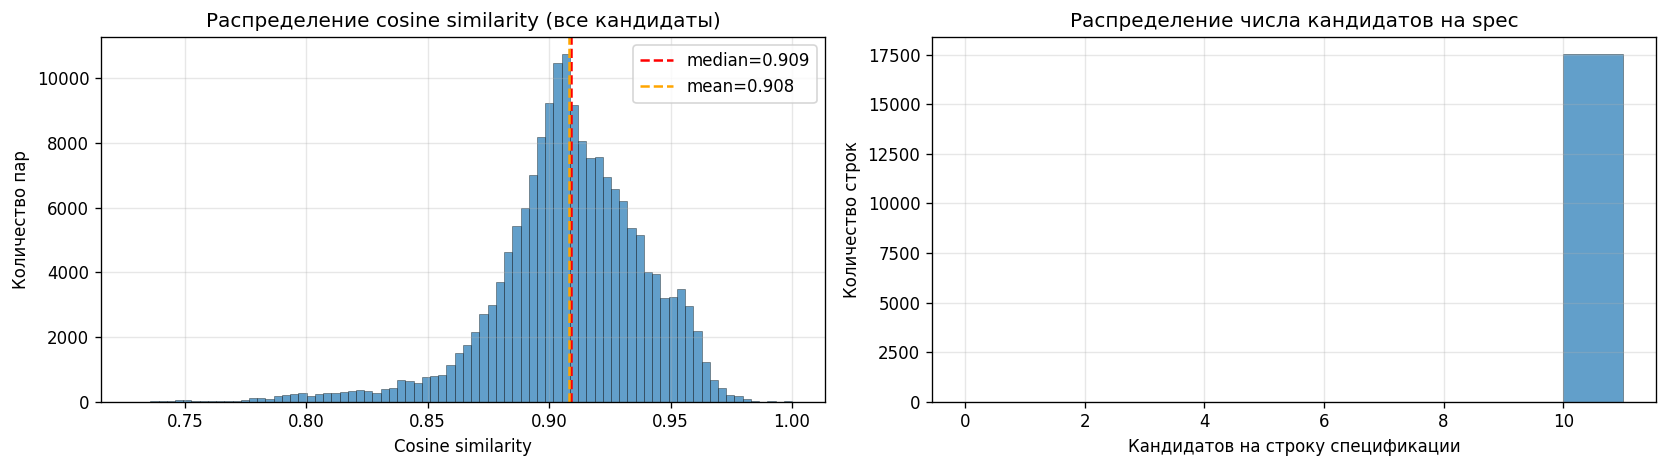


Распределение по бакетам cosine similarity:
  [0.70, 0.75):      90 (  0.1%)
  [0.75, 0.80):   1,423 (  0.8%)
  [0.80, 0.85):   5,767 (  3.3%)
  [0.85, 0.90):  53,420 ( 30.5%)
  [0.90, 0.95): 100,548 ( 57.4%)
  [0.95, 1.00):  13,882 (  7.9%)


In [2]:
candidates = files.get("candidates", df)

print(f"Всего кандидатных пар: {len(candidates):,}")
print(f"Уникальных spec текстов: {candidates['spec_text'].nunique():,}")
print(f"Уникальных nom текстов: {candidates['nom_text'].nunique():,}")
print(f"\nCosine similarity:")
print(candidates["cosine_sim"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма cosine similarity
ax = axes[0]
ax.hist(candidates["cosine_sim"], bins=80, alpha=0.7, edgecolor="black", linewidth=0.3)
ax.axvline(candidates["cosine_sim"].median(), color="red", ls="--", label=f"median={candidates['cosine_sim'].median():.3f}")
ax.axvline(candidates["cosine_sim"].mean(), color="orange", ls="--", label=f"mean={candidates['cosine_sim'].mean():.3f}")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Количество пар")
ax.set_title("Распределение cosine similarity (все кандидаты)")
ax.legend()
ax.grid(True, alpha=0.3)

# Количество кандидатов на spec
cands_per_spec = candidates.groupby("spec_idx").size()
ax = axes[1]
ax.hist(cands_per_spec, bins=range(0, cands_per_spec.max() + 2), alpha=0.7, edgecolor="black", linewidth=0.3)
ax.set_xlabel("Кандидатов на строку спецификации")
ax.set_ylabel("Количество строк")
ax.set_title("Распределение числа кандидатов на spec")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Бакеты по similarity
print("\nРаспределение по бакетам cosine similarity:")
for lo, hi in [(0.70, 0.75), (0.75, 0.80), (0.80, 0.85), (0.85, 0.90), (0.90, 0.95), (0.95, 1.001)]:
    n = ((candidates["cosine_sim"] >= lo) & (candidates["cosine_sim"] < hi)).sum()
    print(f"  [{lo:.2f}, {hi:.2f}): {n:>7,} ({100 * n / len(candidates):5.1f}%)")

## 2. Дедупликация: эффект сжатия

До дедупликации: 175,130 пар
После дедупликации: 26,055 пар
Сжатие: 6.7x

Уникальных spec: 8,685
Уникальных nom: 5,481
Пар на spec: 3.0 (ожидаемо ~3)


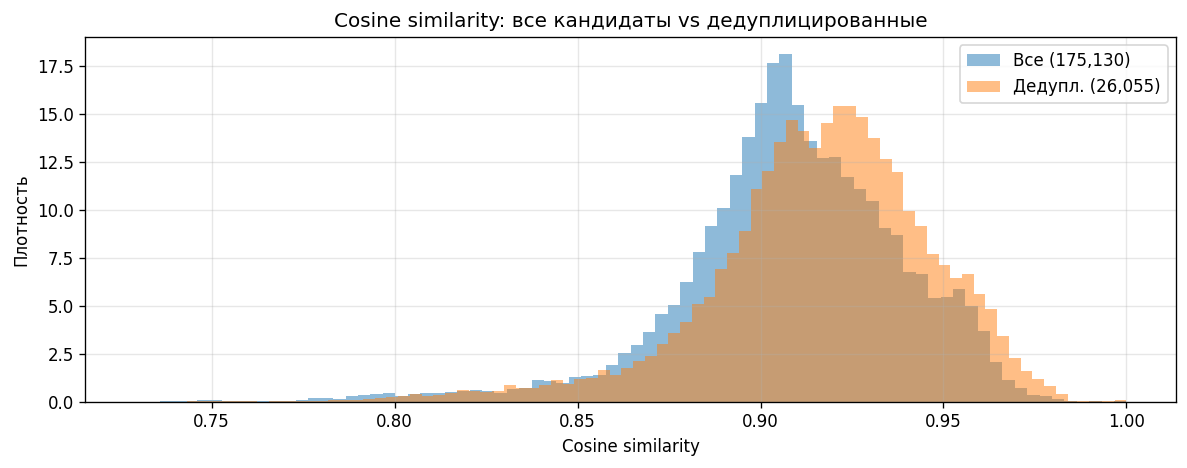

In [3]:
dedup = files.get("candidates_dedup", files.get("labeled_pairs"))

if dedup is not None:
    print(f"До дедупликации: {len(candidates):,} пар")
    print(f"После дедупликации: {len(dedup):,} пар")
    print(f"Сжатие: {len(candidates) / len(dedup):.1f}x")
    print(f"\nУникальных spec: {dedup['spec_text'].nunique():,}")
    print(f"Уникальных nom: {dedup['nom_text'].nunique():,}")
    print(f"Пар на spec: {len(dedup) / dedup['spec_text'].nunique():.1f} (ожидаемо ~3)")
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(candidates["cosine_sim"], bins=80, alpha=0.5, label=f"Все ({len(candidates):,})", density=True)
    ax.hist(dedup["cosine_sim"], bins=80, alpha=0.5, label=f"Дедупл. ({len(dedup):,})", density=True)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Плотность")
    ax.set_title("Cosine similarity: все кандидаты vs дедуплицированные")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Дедуплицированные данные не найдены")

## 3. Результаты LLM-разметки

Всего пар: 26,055
Размечено: 26,055 (100.0%)
  Match:    2,541 (9.8%)
  No match: 23,514 (90.2%)
  Не размечено: 0 (0.0%)


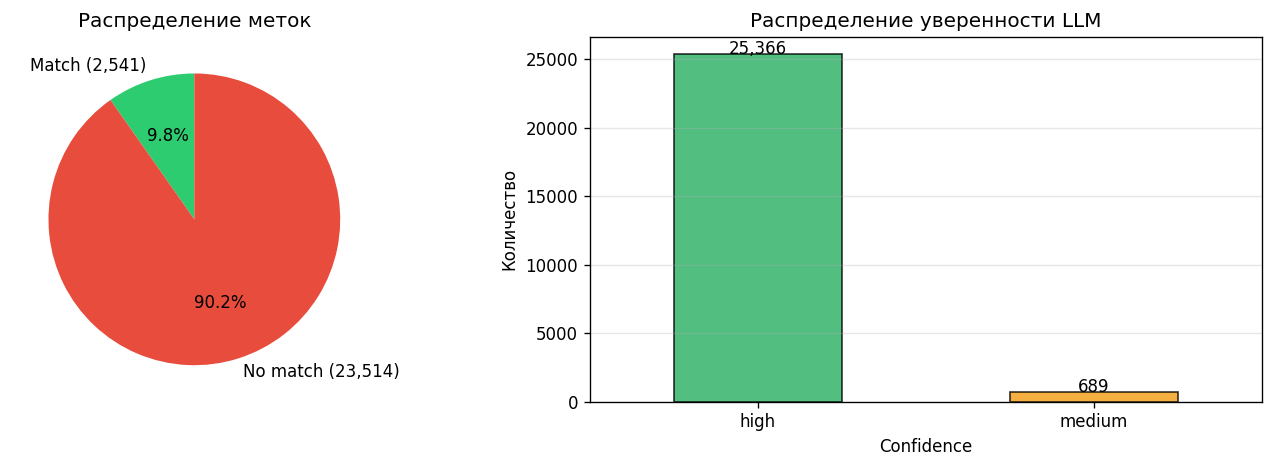

In [4]:
labeled = files.get("labeled_pairs")

if labeled is not None and "label" in labeled.columns:
    total = len(labeled)
    done = (labeled["label"] != -1).sum()
    matches = (labeled["label"] == 1).sum()
    no_matches = (labeled["label"] == 0).sum()
    unlabeled = (labeled["label"] == -1).sum()
    
    print(f"Всего пар: {total:,}")
    print(f"Размечено: {done:,} ({100 * done / total:.1f}%)")
    print(f"  Match:    {matches:,} ({100 * matches / max(done, 1):.1f}%)")
    print(f"  No match: {no_matches:,} ({100 * no_matches / max(done, 1):.1f}%)")
    print(f"  Не размечено: {unlabeled:,} ({100 * unlabeled / total:.1f}%)")
    
    # Pie chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ax = axes[0]
    sizes = [matches, no_matches, unlabeled]
    labels_pie = [f"Match ({matches:,})", f"No match ({no_matches:,})", f"Не размечено ({unlabeled:,})"]
    colors = ["#2ecc71", "#e74c3c", "#bdc3c7"]
    sizes_nonzero = [(s, l, c) for s, l, c in zip(sizes, labels_pie, colors) if s > 0]
    if sizes_nonzero:
        ax.pie([s[0] for s in sizes_nonzero], labels=[s[1] for s in sizes_nonzero],
               colors=[s[2] for s in sizes_nonzero], autopct="%1.1f%%", startangle=90)
    ax.set_title("Распределение меток")
    
    # Confidence distribution
    ax = axes[1]
    if "confidence" in labeled.columns:
        done_df = labeled[labeled["label"] != -1]
        if len(done_df) > 0:
            conf_counts = done_df["confidence"].value_counts()
            conf_order = ["high", "medium", "low"]
            conf_counts = conf_counts.reindex([c for c in conf_order if c in conf_counts.index])
            conf_counts.plot.bar(ax=ax, color=["#27ae60", "#f39c12", "#e74c3c"], alpha=0.8, edgecolor="black")
            for i, v in enumerate(conf_counts):
                ax.text(i, v + 0.5, f"{v:,}", ha="center", fontsize=10)
            ax.set_xlabel("Confidence")
            ax.set_ylabel("Количество")
            ax.set_title("Распределение уверенности LLM")
            ax.tick_params(axis="x", rotation=0)
            ax.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
else:
    print("Размеченные данные не найдены (labeled_pairs.parquet). Запустите 12_label_real_data.py.")

## 4. Cosine similarity vs метка LLM

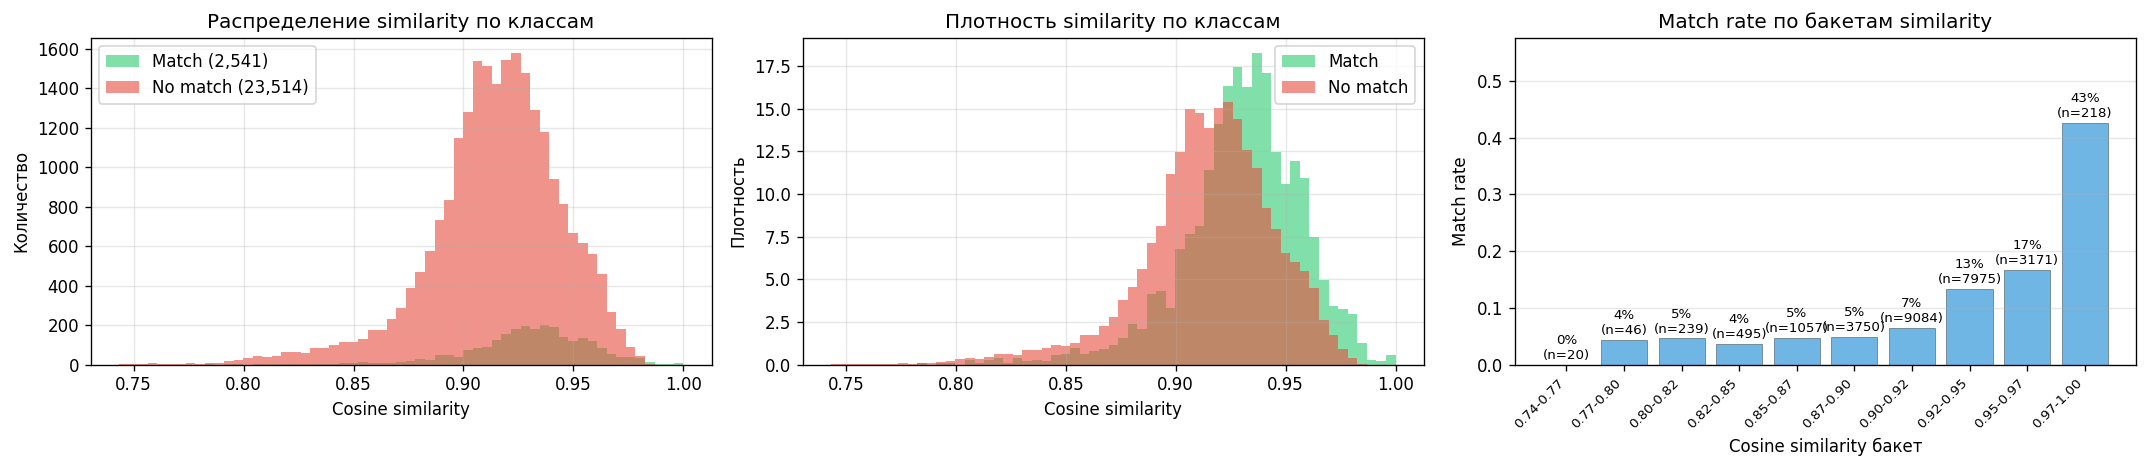

Mean cosine sim — Match: 0.930, No match: 0.915, Delta: 0.015


In [5]:
if labeled is not None and "label" in labeled.columns:
    done_df = labeled[labeled["label"] != -1].copy()
    
    if len(done_df) > 0:
        match_df = done_df[done_df["label"] == 1]
        nomatch_df = done_df[done_df["label"] == 0]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        
        # Гистограммы по классам
        ax = axes[0]
        bins = np.linspace(done_df["cosine_sim"].min(), done_df["cosine_sim"].max(), 60)
        ax.hist(match_df["cosine_sim"], bins=bins, alpha=0.6, label=f"Match ({len(match_df):,})", color="#2ecc71")
        ax.hist(nomatch_df["cosine_sim"], bins=bins, alpha=0.6, label=f"No match ({len(nomatch_df):,})", color="#e74c3c")
        ax.set_xlabel("Cosine similarity")
        ax.set_ylabel("Количество")
        ax.set_title("Распределение similarity по классам")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Нормализованные гистограммы
        ax = axes[1]
        ax.hist(match_df["cosine_sim"], bins=bins, alpha=0.6, label="Match", color="#2ecc71", density=True)
        ax.hist(nomatch_df["cosine_sim"], bins=bins, alpha=0.6, label="No match", color="#e74c3c", density=True)
        ax.set_xlabel("Cosine similarity")
        ax.set_ylabel("Плотность")
        ax.set_title("Плотность similarity по классам")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Match rate по бакетам similarity
        ax = axes[2]
        done_df["sim_bucket"] = pd.cut(done_df["cosine_sim"], bins=10)
        bucket_stats = done_df.groupby("sim_bucket", observed=True).agg(
            total=("label", "count"),
            match_rate=("label", "mean"),
        )
        bucket_stats = bucket_stats[bucket_stats["total"] >= 5]
        
        x_labels = [f"{b.left:.2f}-{b.right:.2f}" for b in bucket_stats.index]
        bars = ax.bar(range(len(bucket_stats)), bucket_stats["match_rate"], alpha=0.7, 
                       color="#3498db", edgecolor="black", linewidth=0.3)
        for i, (rate, total) in enumerate(zip(bucket_stats["match_rate"], bucket_stats["total"])):
            ax.text(i, rate + 0.01, f"{rate:.0%}\n(n={total})", ha="center", fontsize=8)
        ax.set_xticks(range(len(bucket_stats)))
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("Cosine similarity бакет")
        ax.set_ylabel("Match rate")
        ax.set_title("Match rate по бакетам similarity")
        ax.set_ylim(0, min(1.15, bucket_stats["match_rate"].max() + 0.15))
        ax.grid(True, alpha=0.3, axis="y")
        
        plt.tight_layout()
        plt.show()
        
        # Статистика
        print(f"Mean cosine sim — Match: {match_df['cosine_sim'].mean():.3f}, "
              f"No match: {nomatch_df['cosine_sim'].mean():.3f}, "
              f"Delta: {match_df['cosine_sim'].mean() - nomatch_df['cosine_sim'].mean():.3f}")
else:
    print("Размеченные данные не найдены")

## 5. Confidence vs метка: кросс-таблица

label_str,Match,No match,All
confidence,,,
high,2139,23227,25366
medium,402,287,689
All,2541,23514,26055



Match rate по уровню уверенности:
  high    : 8.4% match rate (25,366 пар)
  medium  : 58.3% match rate (689 пар)


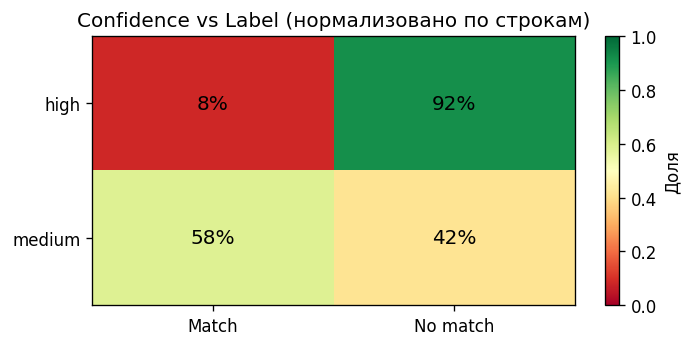

In [6]:
if labeled is not None and "label" in labeled.columns and "confidence" in labeled.columns:
    done_df = labeled[labeled["label"] != -1].copy()
    done_df["label_str"] = done_df["label"].map({1: "Match", 0: "No match"})
    
    if len(done_df) > 0:
        # Кросс-таблица
        ct = pd.crosstab(done_df["confidence"], done_df["label_str"], margins=True)
        display(ct)
        
        # Match rate по confidence
        print("\nMatch rate по уровню уверенности:")
        for conf in ["high", "medium", "low"]:
            subset = done_df[done_df["confidence"] == conf]
            if len(subset) > 0:
                mr = subset["label"].mean()
                print(f"  {conf:8s}: {mr:.1%} match rate ({len(subset):,} пар)")
        
        # Heatmap
        ct_norm = pd.crosstab(done_df["confidence"], done_df["label_str"], normalize="index")
        fig, ax = plt.subplots(figsize=(6, 3))
        im = ax.imshow(ct_norm.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
        ax.set_xticks(range(len(ct_norm.columns)))
        ax.set_xticklabels(ct_norm.columns)
        ax.set_yticks(range(len(ct_norm.index)))
        ax.set_yticklabels(ct_norm.index)
        for i in range(len(ct_norm.index)):
            for j in range(len(ct_norm.columns)):
                ax.text(j, i, f"{ct_norm.values[i, j]:.0%}", ha="center", va="center", fontsize=12)
        plt.colorbar(im, ax=ax, label="Доля")
        ax.set_title("Confidence vs Label (нормализовано по строкам)")
        plt.tight_layout()
        plt.show()
else:
    print("Размеченные данные не найдены")

## 6. Матчи на уровне spec: сколько spec получили хотя бы один match?

Уникальных spec (размеченных): 8,685
  С хотя бы 1 match: 2,050 (23.6%)
  Без match:          6,635 (76.4%)


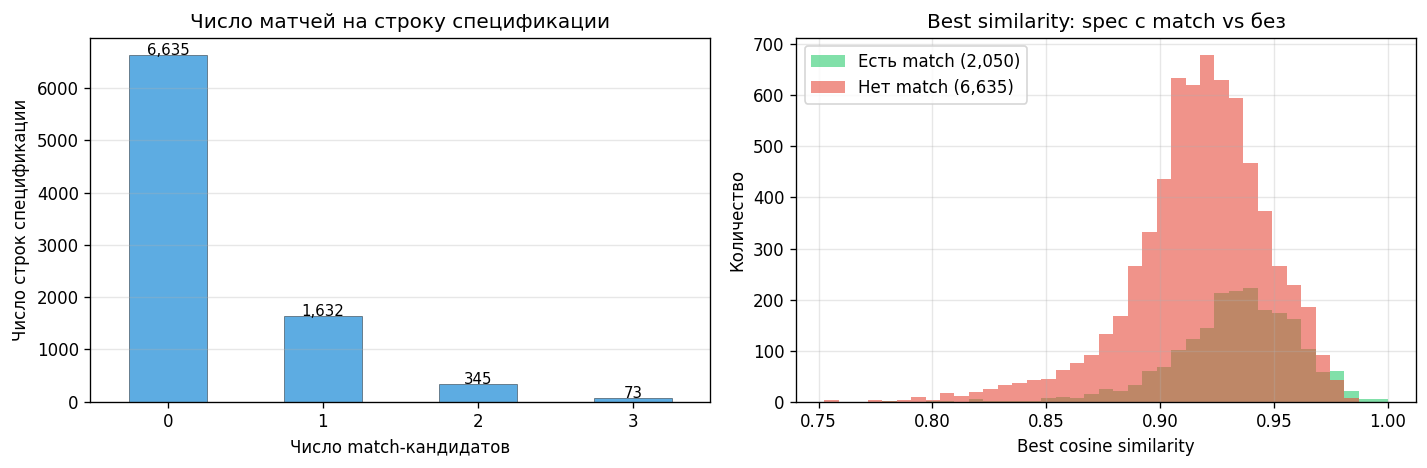

In [7]:
if labeled is not None and "label" in labeled.columns:
    done_df = labeled[labeled["label"] != -1]
    
    if len(done_df) > 0:
        spec_stats = done_df.groupby("spec_text").agg(
            n_candidates=("label", "count"),
            n_matches=("label", "sum"),
            best_sim=("cosine_sim", "max"),
        )
        
        total_specs = spec_stats.shape[0]
        specs_with_match = (spec_stats["n_matches"] > 0).sum()
        specs_no_match = (spec_stats["n_matches"] == 0).sum()
        
        print(f"Уникальных spec (размеченных): {total_specs:,}")
        print(f"  С хотя бы 1 match: {specs_with_match:,} ({100 * specs_with_match / total_specs:.1f}%)")
        print(f"  Без match:          {specs_no_match:,} ({100 * specs_no_match / total_specs:.1f}%)")
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Распределение числа матчей на spec
        ax = axes[0]
        match_counts = spec_stats["n_matches"].value_counts().sort_index()
        match_counts.plot.bar(ax=ax, color="#3498db", alpha=0.8, edgecolor="black", linewidth=0.3)
        for i, (idx, v) in enumerate(match_counts.items()):
            ax.text(i, v + 0.5, f"{v:,}", ha="center", fontsize=9)
        ax.set_xlabel("Число match-кандидатов")
        ax.set_ylabel("Число строк спецификации")
        ax.set_title("Число матчей на строку спецификации")
        ax.tick_params(axis="x", rotation=0)
        ax.grid(True, alpha=0.3, axis="y")
        
        # Best similarity для spec с/без матча
        ax = axes[1]
        with_match = spec_stats[spec_stats["n_matches"] > 0]["best_sim"]
        without_match = spec_stats[spec_stats["n_matches"] == 0]["best_sim"]
        bins = np.linspace(spec_stats["best_sim"].min(), spec_stats["best_sim"].max(), 40)
        if len(with_match) > 0:
            ax.hist(with_match, bins=bins, alpha=0.6, label=f"Есть match ({len(with_match):,})", color="#2ecc71")
        if len(without_match) > 0:
            ax.hist(without_match, bins=bins, alpha=0.6, label=f"Нет match ({len(without_match):,})", color="#e74c3c")
        ax.set_xlabel("Best cosine similarity")
        ax.set_ylabel("Количество")
        ax.set_title("Best similarity: spec с match vs без")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("Размеченные данные не найдены")

## 7. Примеры пар: match vs no match

In [8]:
if labeled is not None and "label" in labeled.columns:
    done_df = labeled[labeled["label"] != -1].copy()
    
    if len(done_df) > 0:
        # Top match пары (высокий cosine sim, match)
        matches_sorted = done_df[done_df["label"] == 1].sort_values("cosine_sim", ascending=False)
        print("=== TOP MATCH (высокий sim, label=1) ===")
        for _, row in matches_sorted.head(10).iterrows():
            print(f"  sim={row['cosine_sim']:.3f} | conf={row.get('confidence', '?'):6s} | "
                  f"SPEC: {row['spec_text'][:60]}")
            print(f"{'':>40s} NOM:  {row['nom_text'][:60]}")
            print()
        
        # Пограничные no-match (высокий sim, но не match)
        nomatch_high = done_df[(done_df["label"] == 0)].sort_values("cosine_sim", ascending=False)
        print("=== TOP NO-MATCH (высокий sim, но label=0) — потенциальные ошибки blocking ===")
        for _, row in nomatch_high.head(10).iterrows():
            print(f"  sim={row['cosine_sim']:.3f} | conf={row.get('confidence', '?'):6s} | "
                  f"SPEC: {row['spec_text'][:60]}")
            print(f"{'':>40s} NOM:  {row['nom_text'][:60]}")
            print()
else:
    print("Размеченные данные не найдены")

=== TOP MATCH (высокий sim, label=1) ===
  sim=1.000 | conf=medium | SPEC: Ручка
                                         NOM:  Ручка

  sim=1.000 | conf=high   | SPEC: Вставка плавкая ВП1-1В 2,0 А 250 В | ОЮ0.480.003 ТУ-Р
                                         NOM:  Вставка плавкая ВП1-1В 2,0 А 250 В –  ОЮ0.480.003 ТУ-Р

  sim=1.000 | conf=high   | SPEC: XCS40-3PQ208I
                                         NOM:  XCS40-3PQ208I

  sim=1.000 | conf=medium | SPEC: Розетки
                                         NOM:  Розетки

  sim=1.000 | conf=high   | SPEC: Вставка плавкая ВП1-1В 5,0 А 250 В | ОЮ0.480.003 ТУ-Р
                                         NOM:  Вставка плавкая ВП1-1В 5,0 А 250 В –  ОЮ0.480.003 ТУ-Р

  sim=0.998 | conf=high   | SPEC: Вставка плавкая ВП1-1В-2,0 А 250 В | ОЮ0.480.003 ТУ-Р
                                         NOM:  Вставка плавкая ВП1-1В 2,0 А 250 В –  ОЮ0.480.003 ТУ-Р

  sim=0.994 | conf=high   | SPEC: Вставка плавкая ВП1-1В-2,0 А-250 В | ОЮ0.480.003 Т

## 8. Оптимальный порог cosine similarity (если бы использовали только FAISS)

ROC-AUC (cosine sim как скор): 0.658
Лучший порог: 0.934 → F1=0.248 (P=0.168, R=0.476)


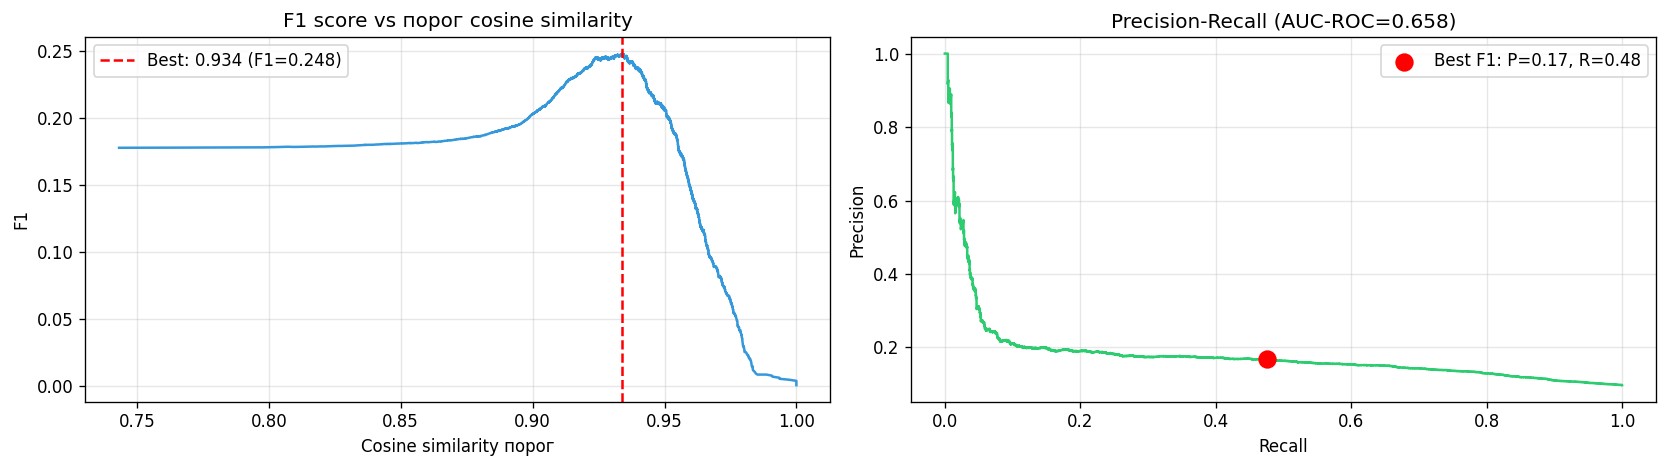

In [9]:
if labeled is not None and "label" in labeled.columns:
    done_df = labeled[labeled["label"] != -1].copy()
    
    if len(done_df) > 0 and done_df["label"].nunique() == 2:
        from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score
        
        y_true = done_df["label"].astype(int).values
        y_score = done_df["cosine_sim"].values
        
        # ROC-AUC
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC (cosine sim как скор): {auc:.3f}")
        
        # Precision-Recall sweep
        prec, rec, thresholds = precision_recall_curve(y_true, y_score)
        f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
        best_idx = f1_scores.argmax()
        best_thresh = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        print(f"Лучший порог: {best_thresh:.3f} → F1={best_f1:.3f} "
              f"(P={prec[best_idx]:.3f}, R={rec[best_idx]:.3f})")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # F1 vs threshold
        ax = axes[0]
        ax.plot(thresholds, f1_scores, color="#3498db", linewidth=1.5)
        ax.axvline(best_thresh, color="red", ls="--", label=f"Best: {best_thresh:.3f} (F1={best_f1:.3f})")
        ax.set_xlabel("Cosine similarity порог")
        ax.set_ylabel("F1")
        ax.set_title("F1 score vs порог cosine similarity")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Precision-Recall curve
        ax = axes[1]
        ax.plot(rec, prec, color="#2ecc71", linewidth=1.5)
        ax.scatter(rec[best_idx], prec[best_idx], color="red", s=100, zorder=5,
                   label=f"Best F1: P={prec[best_idx]:.2f}, R={rec[best_idx]:.2f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"Precision-Recall (AUC-ROC={auc:.3f})")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("Размеченные данные не найдены")

## 9. Прогресс разметки по батчам

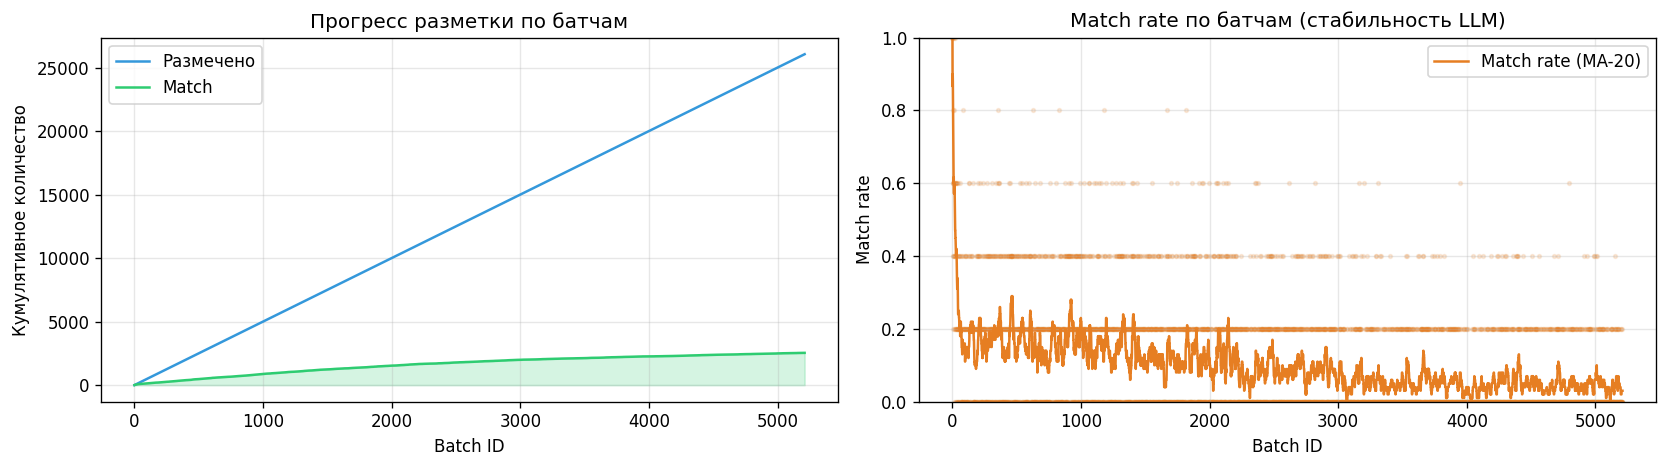

Все батчи полностью размечены


In [10]:
if labeled is not None and "batch_id" in labeled.columns and "label" in labeled.columns:
    batch_stats = labeled.groupby("batch_id").agg(
        total=("label", "count"),
        labeled=("label", lambda x: (x != -1).sum()),
        matches=("label", lambda x: (x == 1).sum()),
    )
    batch_stats["match_rate"] = batch_stats["matches"] / batch_stats["labeled"].clip(lower=1)
    batch_stats["cum_labeled"] = batch_stats["labeled"].cumsum()
    batch_stats["cum_matches"] = batch_stats["matches"].cumsum()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Кумулятивный прогресс
    ax = axes[0]
    ax.plot(batch_stats.index, batch_stats["cum_labeled"], label="Размечено", color="#3498db")
    ax.plot(batch_stats.index, batch_stats["cum_matches"], label="Match", color="#2ecc71")
    ax.fill_between(batch_stats.index, 0, batch_stats["cum_matches"], alpha=0.2, color="#2ecc71")
    ax.set_xlabel("Batch ID")
    ax.set_ylabel("Кумулятивное количество")
    ax.set_title("Прогресс разметки по батчам")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Match rate по батчам (скользящее среднее)
    ax = axes[1]
    window = min(20, len(batch_stats) // 5 + 1)
    rolling_mr = batch_stats["match_rate"].rolling(window, min_periods=1).mean()
    ax.plot(batch_stats.index, rolling_mr, color="#e67e22", linewidth=1.5,
            label=f"Match rate (MA-{window})")
    ax.scatter(batch_stats.index, batch_stats["match_rate"], alpha=0.15, s=5, color="#e67e22")
    ax.set_xlabel("Batch ID")
    ax.set_ylabel("Match rate")
    ax.set_title("Match rate по батчам (стабильность LLM)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Ошибки разметки (батчи где не все строки размечены)
    incomplete = batch_stats[batch_stats["labeled"] < batch_stats["total"]]
    if len(incomplete) > 0:
        print(f"Неполные батчи (LLM не разметил все пары): {len(incomplete)}")
        print(f"  Пропущено строк: {(batch_stats['total'] - batch_stats['labeled']).sum()}")
    else:
        print("Все батчи полностью размечены")
else:
    print("Данные о батчах не найдены")

## 10. Развёрнутые метки: полная картина

In [11]:
full = files.get("labeled_pairs_full")

if full is not None and "label" in full.columns:
    total = len(full)
    has_label = full["label"].notna() & (full["label"] != -1)
    n_labeled = has_label.sum()
    n_match = (full["label"] == 1).sum()
    n_nomatch = (full["label"] == 0).sum()
    
    print(f"Полный датасет (с развёрнутыми метками): {total:,} пар")
    print(f"С метками: {n_labeled:,} ({100 * n_labeled / total:.1f}%)")
    print(f"  Match:    {n_match:,}")
    print(f"  No match: {n_nomatch:,}")
    print(f"Без меток:  {total - n_labeled:,}")
    
    # Сравнение дедупл vs полная
    if labeled is not None:
        print(f"\nДедуплицированные: {len(labeled):,} пар → Полные: {total:,} пар")
        print(f"Коэф. развёртки: {total / len(labeled):.1f}x")
else:
    print("labeled_pairs_full.parquet не найден")

Полный датасет (с развёрнутыми метками): 175,130 пар
С метками: 52,939 (30.2%)
  Match:    5,331
  No match: 47,608
Без меток:  122,191

Дедуплицированные: 26,055 пар → Полные: 175,130 пар
Коэф. развёртки: 6.7x


## 11. Итоговая сводка

In [12]:
print("=" * 60)
print("РАЗМЕТКА РЕАЛЬНЫХ ДАННЫХ — СВОДКА")
print("=" * 60)

if "candidates" in files:
    c = files["candidates"]
    print(f"\n1. FAISS blocking:")
    print(f"   Кандидатных пар: {len(c):,}")
    print(f"   Уник. spec: {c['spec_text'].nunique():,}, уник. nom: {c['nom_text'].nunique():,}")
    print(f"   Cosine sim: mean={c['cosine_sim'].mean():.3f}, median={c['cosine_sim'].median():.3f}")

if labeled is not None and "label" in labeled.columns:
    done = labeled[labeled["label"] != -1]
    n_m = (done["label"] == 1).sum()
    n_nm = (done["label"] == 0).sum()
    print(f"\n2. LLM-разметка (дедупл.):")
    print(f"   Всего пар: {len(labeled):,}")
    print(f"   Размечено: {len(done):,} ({100 * len(done) / len(labeled):.1f}%)")
    print(f"   Match: {n_m:,} ({100 * n_m / max(len(done), 1):.1f}%)")
    print(f"   No match: {n_nm:,} ({100 * n_nm / max(len(done), 1):.1f}%)")
    print(f"   Match rate: {n_m / max(len(done), 1):.1%}")

if full is not None and "label" in full.columns:
    fl = full[full["label"].notna() & (full["label"] != -1)]
    print(f"\n3. Полный датасет (с развёрткой):")
    print(f"   Пар с метками: {len(fl):,} / {len(full):,}")

print("\n" + "=" * 60)

РАЗМЕТКА РЕАЛЬНЫХ ДАННЫХ — СВОДКА

1. FAISS blocking:
   Кандидатных пар: 175,130
   Уник. spec: 8,685, уник. nom: 10,649
   Cosine sim: mean=0.908, median=0.909

2. LLM-разметка (дедупл.):
   Всего пар: 26,055
   Размечено: 26,055 (100.0%)
   Match: 2,541 (9.8%)
   No match: 23,514 (90.2%)
   Match rate: 9.8%

3. Полный датасет (с развёрткой):
   Пар с метками: 52,939 / 175,130

